# difmap-python — Démonstration complète

Ce notebook démontre le **workflow complet d'imagerie radio-interférométrique** :
du fichier UVFITS brut jusqu'à la Clean Map finale avec boucle d'auto-calibration.

| Étape | Commande Difmap équivalente |
|---|---|
| Chargement | `observe` |
| Sélection | `select` |
| UV Coverage | `uvplot` |
| Amplitude vs rayon UV | `radplot` |
| Dirty Map | `invert` |
| Déconvolution CLEAN | `clean` |
| Auto-calibration | `selfcal` |
| Carte finale | `restore` |

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'builddir'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 13,
})

from difmap_wrapper.session import DifmapSession

# Réinitialisation propre si le notebook est relancé
DifmapSession._instance = None
print('Imports OK')

Imports OK


---
## 1 · Chargement du fichier UVFITS

In [2]:
DATA_FILE = 'tests/test_data/0003-066_X.SPLIT.1'

session = DifmapSession()
session.observe(DATA_FILE)

print(f'Source       : {session.obs.source}')
print(f'Sous-réseaux : {session.obs.nsub()}')

Source       : 0003-066
Sous-réseaux : 5
Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07          1      1.6e+07
 03        3  8.81372e+

---
## 2 · Sélection de la polarisation et de tous les IFs

`ifs=(1, 0)` → tous les IFs du début jusqu'au dernier (convention difmap : 0 = dernier)

In [3]:
pol_selectionnee = session.obs.select(pol='I', ifs=(1, 0), channels=(1, 0))

data = session.obs.get_data()
n_vis = len(data['u'])
n_ifs = len(np.unique(data['if_no']))
n_ants = len(np.unique(np.concatenate([data['tel_a'], data['tel_b']])))
uv_max_Ml = np.sqrt(data['u']**2 + data['v']**2).max() / 1e6

print(f'Polarisation chargée : {pol_selectionnee}')
print(f'Visibilités totales  : {n_vis:,}')
print(f'IFs sélectionnés     : {n_ifs}')
print(f'Antennes             : {n_ants}')
print(f'Rayon UV max         : {uv_max_Ml:.0f} Mλ')
print(f'Amplitude médiane    : {np.median(data["amp"]):.4f} Jy')

Polarisation I indisponible. Le moteur a basculé sur RR.


Selecting polarization: RR,  channels: 1..4
Reading IF 1 channels: 1..1
Reading IF 2 channels: 2..2
Reading IF 3 channels: 3..3
Reading IF 4 channels: 4..4
Polarisation chargée : RR
Visibilités totales  : 13,072
IFs sélectionnés     : 4
Antennes             : 14
Rayon UV max         : 303 Mλ
Amplitude médiane    : 2.9640 Jy


Polarization I is unavailable.


---
## 3 · UV Coverage — couverture du plan UV

Chaque point représente une mesure de corrélation entre deux antennes.
Les points conjugués (−U, −V) sont ajoutés automatiquement.

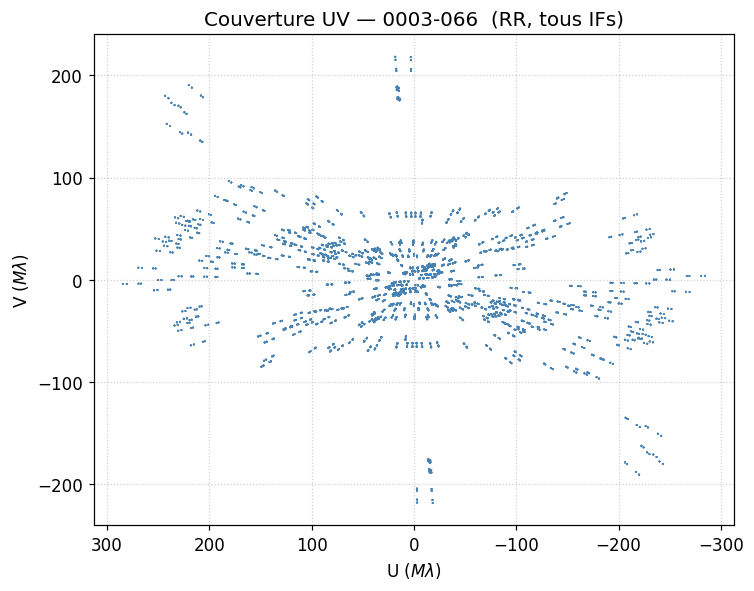

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
session.vis.uvplot(
    ax=ax,
    color='steelblue',
    s=1.5,
    alpha=0.45,
    title=f'Couverture UV — {session.obs.source}  ({pol_selectionnee}, tous IFs)',
)
plt.tight_layout()
plt.show()

---
## 4 · Radplot — amplitude en fonction du rayon UV

Une source ponctuelle donne une ligne plate ; une structure étendue montre une décroissance.

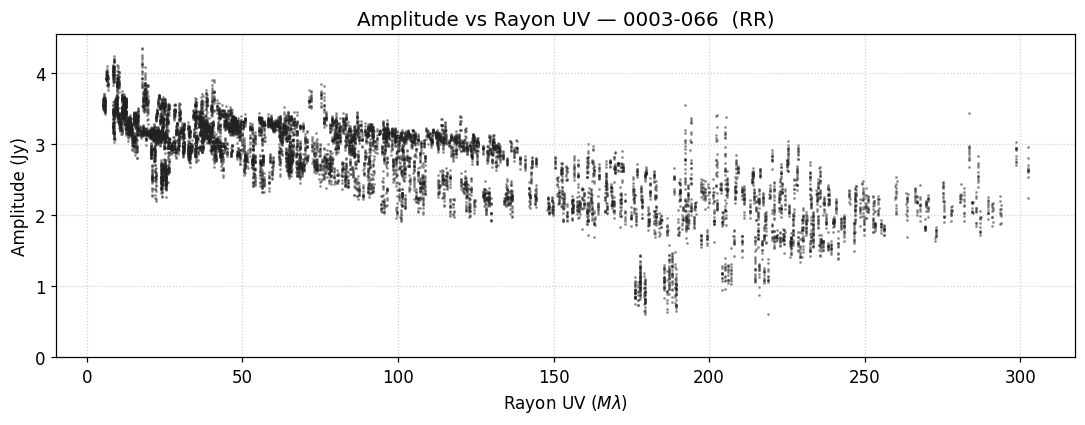

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
session.vis.radplot(
    ax=ax,
    color='#222222',
    s=1,
    alpha=0.35,
    title=f'Amplitude vs Rayon UV — {session.obs.source}  ({pol_selectionnee})',
)
plt.tight_layout()
plt.show()

---
## 5 · Dirty Map — transformée de Fourier inverse

La **Dirty Map** est la reconstruction brute sans déconvolution.
Elle est convoluée par le **Dirty Beam** (lobes d'interférence).

In [6]:
# Paramètres d'imagerie (à adapter selon la résolution de la source)
MAP_SIZE   = 512      # pixels × pixels
CELLSIZE   = 0.1      # mas/pixel

# Pondération uniforme classique
session.imager.uvweight(bin_size=2.0, err_power=0.0)

# Calcul de la Dirty Map
session.imager.mapsize(MAP_SIZE, CELLSIZE)
session.imager.invert()
dirty = session.imager.get_map_package(cellsize=CELLSIZE)

# Statistiques
p_dirty = session.imager.peak()
print(f"Dirty Map  — Pic : {p_dirty['flux']:.4f} Jy/beam")
print(f"           Bruit : {p_dirty['rms']:.4f} Jy/beam")
print(f"           SNR   : {p_dirty['snr']:.1f}")
print(f"Beam : {dirty['info']['bmaj']:.3f} × {dirty['info']['bmin']:.3f} mas  BPA={dirty['info']['bpa']:.1f}°")

Nouvelle pondération appliquée : bin_size=2.0, err_power=0.0, radial=Non
Inverting map and beam Dirty Map  — Pic : 2.5509 Jy/beam
           Bruit : 0.1212 Jy/beam
           SNR   : 21.0
Beam : 0.000 × 0.000 mas  BPA=0.0°

Estimated beam: bmin=0.5457 mas, bmaj=1.323 mas, bpa=-9.027 degrees
Estimated noise=1.57154 mJy/beam.


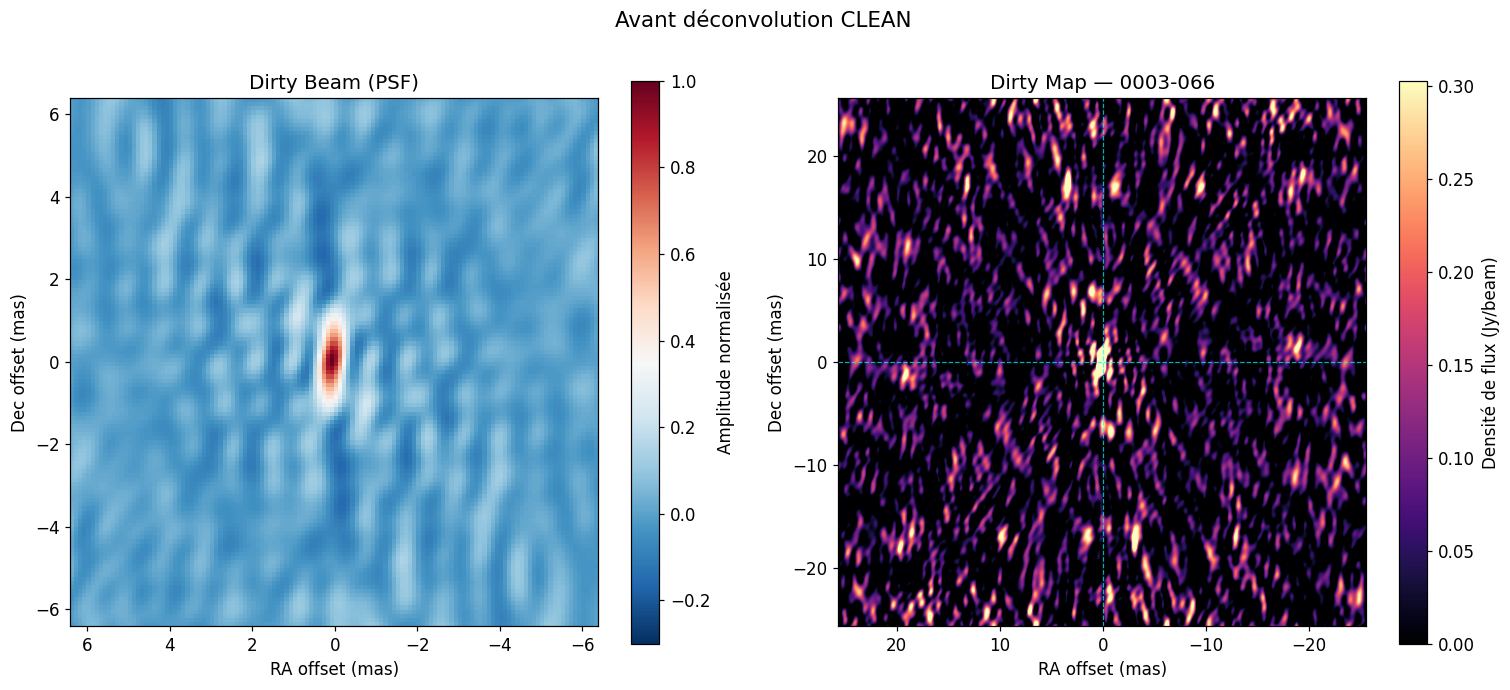

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Dirty Beam (PSF) ---
ax_beam = axes[0]
beam_data = dirty['beam_data']
ny, nx = beam_data.shape
cx, cy = nx // 2, ny // 2
crop = 64
beam_crop = beam_data[cy-crop:cy+crop, cx-crop:cx+crop]
ext_beam = np.array(dirty['extent']) * (2*crop / MAP_SIZE)

im_b = ax_beam.imshow(beam_crop, origin='lower', cmap='RdBu_r',
                       extent=ext_beam, vmin=-0.3, vmax=1.0)
ax_beam.set_title('Dirty Beam (PSF)')
ax_beam.set_xlabel('RA offset (mas)')
ax_beam.set_ylabel('Dec offset (mas)')
plt.colorbar(im_b, ax=ax_beam, label='Amplitude normalisée')

# --- Dirty Map ---
ax_map = axes[1]
vmax = np.percentile(dirty['data'], 99.5)
im_d = ax_map.imshow(dirty['data'], origin='lower', cmap='magma',
                      extent=dirty['extent'], vmin=0, vmax=vmax)
ax_map.set_title(f"Dirty Map — {session.obs.source}")
ax_map.set_xlabel('RA offset (mas)')
ax_map.set_ylabel('Dec offset (mas)')
plt.colorbar(im_d, ax=ax_map, label='Densité de flux (Jy/beam)')

# Marqueur du pic
ax_map.axhline(p_dirty['y'], color='cyan', lw=0.8, ls='--', alpha=0.7)
ax_map.axvline(p_dirty['x'], color='cyan', lw=0.8, ls='--', alpha=0.7)

plt.suptitle('Avant déconvolution CLEAN', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 6 · Boucle CLEAN + Auto-calibration

Le workflow standard en radio-interférométrie VLBI :

```
invert → peakwin → clean → selfcal(phase) → [repeat] → selfcal(amp+phase) → restore
```

Chaque passage améliore le modèle de source **et** les gains d'antennes.

In [8]:
# ---- Paramètres de la boucle ----
NITER_CLEAN  = 200      # itérations CLEAN par passe
GAIN_CLEAN   = 0.05     # gain de boucle (fraction du pic soustrait)
WINDOW_SIZE  = 2.0      # taille fenêtre peakwin (× FWHM beam)
N_PHASE_ONLY = 3        # passes selfcal phase seule
N_AMP_PHASE  = 2        # passes selfcal amplitude + phase

# ---- Historique des métriques ----
history = {'pass': [], 'peak': [], 'rms': [], 'snr': []}

def log_metrics(label):
    p = session.imager.peak()
    history['pass'].append(label)
    history['peak'].append(p['flux'])
    history['rms'].append(p['rms'])
    history['snr'].append(p['snr'])
    print(f"  [{label:20s}]  Pic={p['flux']:.4f} Jy/b   Bruit={p['rms']:.4f} Jy/b   SNR={p['snr']:.0f}")

print('=== Début de la boucle CLEAN + selfcal ===')
print()

# --- Passe initiale (sans selfcal) ---
session.imager.mapsize(MAP_SIZE, CELLSIZE)
session.imager.invert()
log_metrics('Dirty (départ)')

session.imager.peakwin(size=WINDOW_SIZE)
session.imager.clean(NITER_CLEAN, GAIN_CLEAN)
session.imager.mapsize(MAP_SIZE, CELLSIZE)
session.imager.invert()
log_metrics('Après 1er CLEAN')

print()
print(f'--- {N_PHASE_ONLY} passes selfcal PHASE SEULE ---')

for i in range(N_PHASE_ONLY):
    session.imager.selfcal(doamp=False)
    session.imager.mapsize(MAP_SIZE, CELLSIZE)
    session.imager.invert()
    session.imager.delwin()
    session.imager.peakwin(size=WINDOW_SIZE)
    session.imager.clean(NITER_CLEAN, GAIN_CLEAN)
    session.imager.mapsize(MAP_SIZE, CELLSIZE)
    session.imager.invert()
    log_metrics(f'Phase selfcal #{i+1}')

print()
print(f'--- {N_AMP_PHASE} passes selfcal AMP+PHASE ---')

for i in range(N_AMP_PHASE):
    session.imager.selfcal(doamp=True)
    session.imager.mapsize(MAP_SIZE, CELLSIZE)
    session.imager.invert()
    session.imager.delwin()
    session.imager.peakwin(size=WINDOW_SIZE)
    session.imager.clean(NITER_CLEAN * 2, GAIN_CLEAN)
    session.imager.mapsize(MAP_SIZE, CELLSIZE)
    session.imager.invert()
    log_metrics(f'Amp+Phase #{i+1}')

print()
print('--- Restauration finale ---')
session.imager.restore()
clean_pkg = session.imager.get_map_package(cellsize=CELLSIZE)
p_clean = session.imager.peak()
log_metrics('Clean Map finale')
print()
print(f'Gain en SNR : ×{p_clean["snr"] / history["snr"][0]:.1f} par rapport à la Dirty Map')

=== Début de la boucle CLEAN + selfcal ===

  [Dirty (départ)      ]  Pic=2.5509 Jy/b   Bruit=0.1212 Jy/b   SNR=21
Inverting map and beam 
Estimated beam: bmin=0.5457 mas, bmaj=1.323 mas, bpa=-9.027 degrees
Estimated noise=1.57154 mJy/beam.
Added new window around map position (0, 0).
Component: 050  -  total flux cleaned = 2.40333 Jy
Component: 100  -  total flux cleaned = 2.90967 Jy
Component: 150  -  total flux cleaned = 3.14063 Jy
Component: 200  -  total flux cleaned = 3.21729 Jy
Total flux subtracted in 200 components = 3.21729 Jy
Clean residual min=-0.060080 max=0.076736 Jy/beam
Clean residual mean=0.000402 rms=0.013965 Jy/beam
Adding 31 model components to the UV plane model.
The established model now contains 31 components and 3.21729 Jy
Inverting map and beam 
Estimated beam: bmin=0.5457 mas, bmaj=1.323 mas, bpa=-9.027 degrees
Estimated noise=1.57154 mJy/beam.
  [Après 1er CLEAN     ]  Pic=0.0767 Jy/b   Bruit=0.0140 Jy/b   SNR=5

--- 3 passes selfcal PHASE SEULE ---

Correcti

---
## 7 · Convergence de la boucle CLEAN

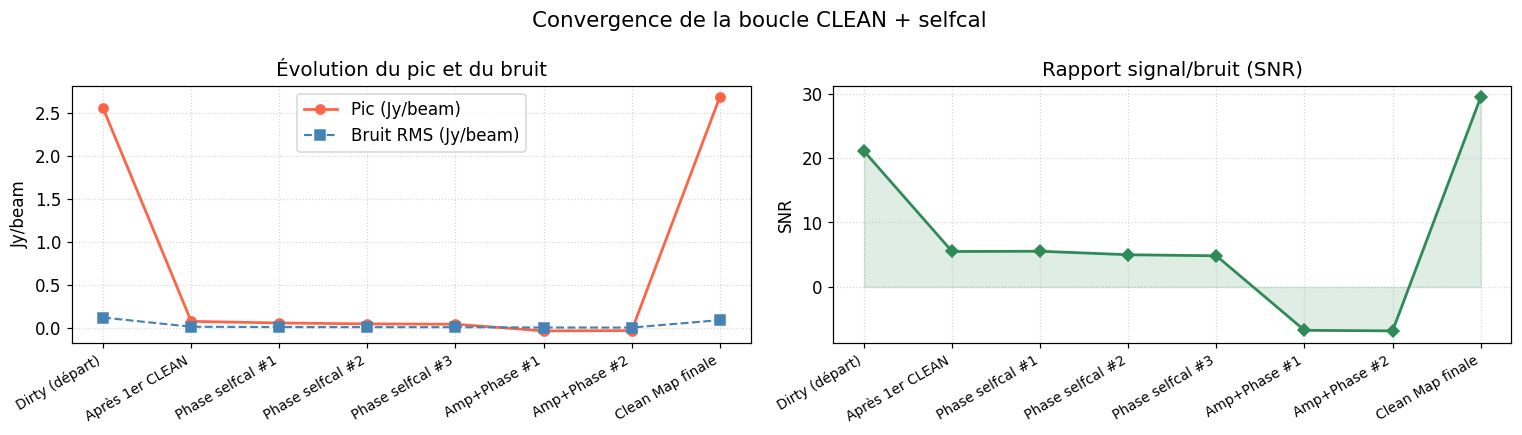

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = range(len(history['pass']))
labels = history['pass']

ax1 = axes[0]
ax1.plot(x, history['peak'], 'o-', color='tomato', lw=1.8, label='Pic (Jy/beam)')
ax1.plot(x, history['rms'],  's--', color='steelblue', lw=1.4, label='Bruit RMS (Jy/beam)')
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Jy/beam')
ax1.set_title('Évolution du pic et du bruit')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.5)

ax2 = axes[1]
ax2.plot(x, history['snr'], 'D-', color='seagreen', lw=1.8)
ax2.fill_between(x, history['snr'], alpha=0.15, color='seagreen')
ax2.set_xticks(list(x))
ax2.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('SNR')
ax2.set_title('Rapport signal/bruit (SNR)')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Convergence de la boucle CLEAN + selfcal', fontsize=14)
plt.tight_layout()
plt.show()

---
## 8 · Résultat final — Dirty Map vs Clean Map

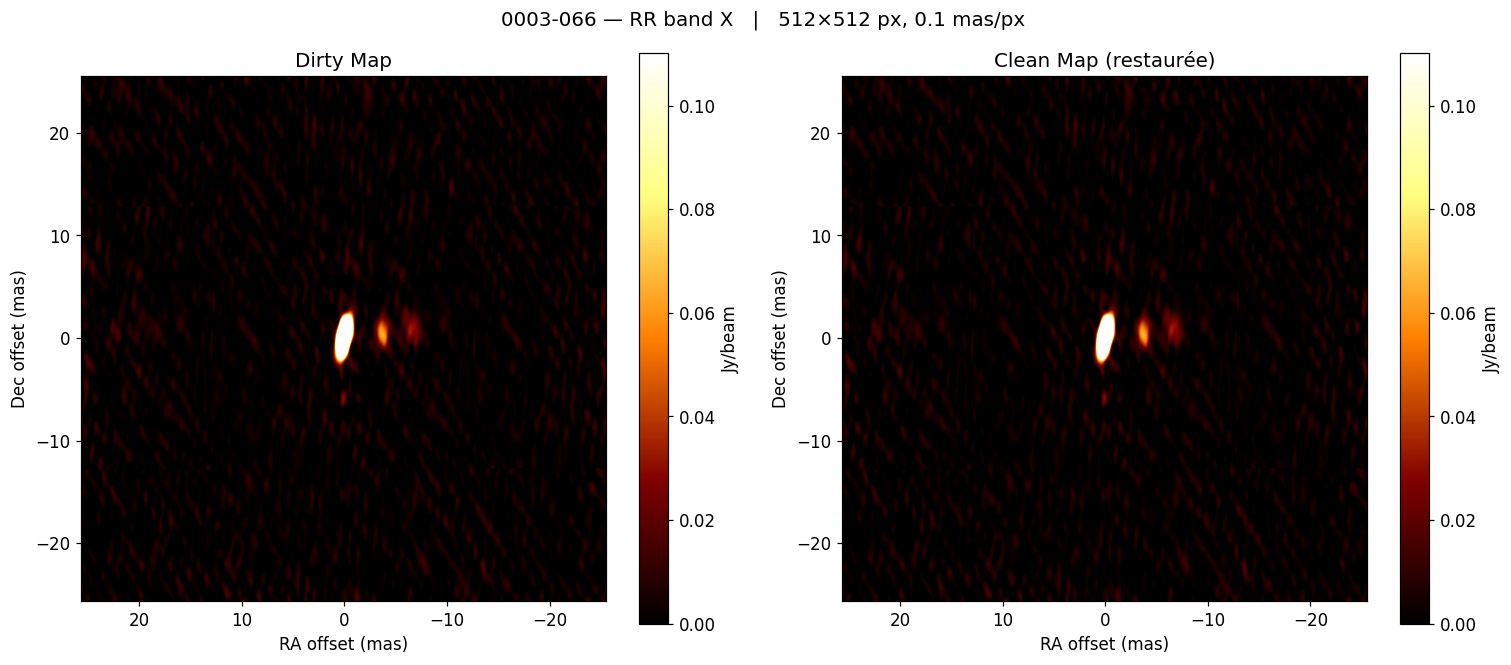

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cmap = 'afmhot'

for ax, pkg, title, p in [
    (axes[0], dirty,      'Dirty Map',             history['peak'][0]),
    (axes[1], clean_pkg,  'Clean Map (restaurée)',  p_clean['flux']),
]:
    d = pkg['data']
    vmax = np.percentile(d, 99.8)
    vmin = 0

    im = ax.imshow(d, origin='lower', cmap=cmap,
                   extent=pkg['extent'], vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('RA offset (mas)')
    ax.set_ylabel('Dec offset (mas)')
    plt.colorbar(im, ax=ax, label='Jy/beam')

plt.suptitle(f"{session.obs.source} — {pol_selectionnee} band X   |   {MAP_SIZE}×{MAP_SIZE} px, {CELLSIZE} mas/px",
             fontsize=13)
plt.tight_layout()
plt.show()

---
## 9 · Sauvegarde FITS

In [11]:
output_fits = f"{session.obs.source}_clean_map.fits"
session.imager.wfits(output_fits)
print(f"Image FITS sauvegardée : {output_fits}")

# Résumé final
print()
print('=== Résumé ===')
print(f'Source         : {session.obs.source}')
print(f'Polarisation   : {pol_selectionnee}')
print(f'Grille         : {MAP_SIZE}×{MAP_SIZE} px  |  {CELLSIZE} mas/px')
print(f'Beam           : {clean_pkg["info"]["bmaj"]:.3f} × {clean_pkg["info"]["bmin"]:.3f} mas  BPA={clean_pkg["info"]["bpa"]:.1f}°')
print(f'Pic final      : {p_clean["flux"]:.4f} Jy/beam')
print(f'Bruit RMS      : {clean_pkg["info"]["rms"]:.4f} Jy/beam')
print(f'SNR final      : {p_clean["snr"]:.0f}')

session.cleanup()

AttributeError: 'DifmapImager' object has no attribute 'wfits'